## LIBRARIES

In [1]:
import os
import sys
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import SpectralClustering
from sklearn.cluster import AffinityPropagation
from sklearn_extra.cluster import KMedoids
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadr
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import rand_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import roc_auc_score
from scipy.spatial.distance import pdist
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import silhouette_score

import gower
from sklearn.metrics.pairwise import euclidean_distances
from scipy.spatial.distance import pdist
import time
from collections import Counter


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap

import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

import sklearn
import sklearn_extra
import matplotlib



In [2]:
### CHECK VERSIONS OF LIBRARIES ###

print("OS:", os.name)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("scikit-learn-extra:", sklearn_extra.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("pyreadr:", pyreadr.__version__)
print("shap:", shap.__version__)
print("statsmodels:", sm.__version__)

OS: posix
pandas: 2.3.3
numpy: 2.3.5
scikit-learn: 1.7.2
scikit-learn-extra: 0.3.0
matplotlib: 3.10.7
seaborn: 0.13.2
pyreadr: 0.5.3
shap: 0.50.0
statsmodels: 0.14.5


## DATA 

In [3]:
# Get the directory where the script is located
soprani_path = os.path.dirname(os.path.abspath(os.getcwd()))
print(f"Program path: {soprani_path}")


Program path: /Users/achacko/Library/CloudStorage/OneDrive-UMCUtrecht/CLUSTERING PROJECT


In [5]:
# Load data and get information about variables
df = sns.load_dataset ("iris")  # Example dataset; 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
# Make a copy of the original data before scaling for visualisation purposes
df2=df


# Scaling the data
columns_to_scale = [
    'sepal_length', 'sepal_width', 'petal_length', 'petal_width'
]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[columns_to_scale])
scaled_df = pd.DataFrame(scaled_data, columns=columns_to_scale)
non_scaled_columns = [
    col for col in df.columns if col not in columns_to_scale
]

df = pd.concat(
    [df[non_scaled_columns], scaled_df], axis=1)

In [8]:
# Define features for clustering

features=columns_to_scale

In [9]:
df1=df

#Filtering df to only include clustering features
df=df[features]


df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   species       150 non-null    object 
 1   sepal_length  150 non-null    float64
 2   sepal_width   150 non-null    float64
 3   petal_length  150 non-null    float64
 4   petal_width   150 non-null    float64
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [11]:
# Computing Gower distance matrix
gower_matrix = gower.gower_matrix(df)

## SILHOUETTE METHODS

Steps involved in computing the optimal number of clusters using the silhouette index:

- Define the candidate cluster range,  n_clusters from  2 to 25.
- Fit the clustering model on the dataset with the predefined distance metric and clustering algorithm.
- Compute the aggregate [silhouette score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) for each value of n_cluster.
- Select the smallest n_cluster with the maximum mean silhouette score as the optimal number of cluster.

In [12]:
# Defining silhouette function for K-medoids

def sil_kmedoids(data, metric, method, max_iter, random_state):

    # Setting initial values
    max_silhouette_avg = -1
    best_n_clusters = -1
    silhouette_values = []
    cluster_label=[]
    wcss = []  
    for n_clusters in range(2,26):
  # Fitting K-medoids clustering with specified number of clusters and predefined distance metric
      
        clusterer = KMedoids(n_clusters=n_clusters,method=method,metric=metric,random_state=random_state,max_iter=max_iter).fit(data)  

        cluster_labels = clusterer.labels_
        
        if len(set(cluster_labels)) == 1:
            silhouette_avg = 0
        else:
            # Calculating silhouette score
            silhouette_avg = silhouette_score(data, cluster_labels)

        silhouette_values.append(silhouette_avg)

        if silhouette_avg > max_silhouette_avg:
            max_silhouette_avg = silhouette_avg
            best_n_clusters = n_clusters
            cluster_label=cluster_labels

    # Returning best number of clusters, silhouette values and cluster labels
    return best_n_clusters, silhouette_values, cluster_label

In [13]:
# Defining silhouette function for Agglomerative clustering
def sil_agg(data, metric,linkage):
    # Setting initial values
    max_silhouette_avg = -1
    best_n_clusters = -1
    silhouette_values = []
    cluster_label=[]

    for n_clusters in range(2,26):
        # Fitting Agglomerative clustering with specified number of clusters and predefined distance metric
        clusterer = AgglomerativeClustering(n_clusters=n_clusters,metric=metric,linkage=linkage).fit(data)

        cluster_labels = clusterer.labels_

        if len(set(cluster_labels)) == 1:
            silhouette_avg = 0
        else:
            # Calculating silhouette score
            silhouette_avg = silhouette_score(data, cluster_labels)

        silhouette_values.append(silhouette_avg)

        if silhouette_avg > max_silhouette_avg:
            max_silhouette_avg = silhouette_avg
            best_n_clusters = n_clusters
            cluster_label=cluster_labels
            
    # Returning best number of clusters, silhouette values and cluster labels
    return best_n_clusters, silhouette_values, cluster_label

In [14]:
# Defining silhouette function for Spectral clustering
def sil_spec(data,seed, n_init, gamma, affinity, n_neighbors,  degree):
    # Setting initial values
    max_silhouette_avg = -1
    best_n_clusters = -1
    silhouette_values = []
    cluster_label=[]

    for n_clusters in range(2,26):
        # Fitting Spectral clustering with specified number of clusters and predefined distance metric
        clusterer = SpectralClustering(n_clusters=n_clusters,affinity=affinity,random_state=seed,n_init=n_init,gamma=gamma,n_neighbors=n_neighbors,degree=degree).fit(data)

        cluster_labels = clusterer.labels_

        if len(set(cluster_labels)) == 1:
            silhouette_avg = 0
        else:
            # Calculating silhouette score
            silhouette_avg = silhouette_score(data, cluster_labels)

        silhouette_values.append(silhouette_avg)

        if silhouette_avg > max_silhouette_avg:
            max_silhouette_avg = silhouette_avg
            best_n_clusters = n_clusters
            cluster_label=cluster_labels

    # Returning best number of clusters, silhouette values and cluster labels
    return best_n_clusters, silhouette_values, cluster_label


## GAP STATISTIC

Steps involved in computing the optimal number of clusters using the gap statistic:

- Define the candidate cluster range,  n_clusters(K) from  1 to 25.
- Fit the clustering model on the dataset with the predefined distance metric and clustering algorithm.
- Compute the within cluster dispersion using the same predefined distance metric $d(\cdot,\cdot)$ as 
$$W_k=\sum_{i=1}^K\frac{1}{2|C_k|}\sum_{x_i,x_j \in C_k}d(x_i,x_j)$$
- Generate reference datatsets under the null hypothesis that the data contains no cluster structure. 
- Compute the within cluster dispersion for the reference datasets, $W^*_{kb}$.
- Compute the gap statistic for each value of n_cluster(k)
$$Gap(k)=\frac{1}{B}\sum_{b=1}^B \log W^*_{kb}-\log W_k$$
- Select the optimal number of clusters such that 
$$
\operatorname{Gap}(K) \ge \operatorname{Gap}(K+1)-s_{K+1}
$$ 

In [20]:

## Function to compute Wk for K-medoids clustering
def km_calc_Wks(data, method, metric, random_state, max_iter):
    
    if metric == 'euclidean':
        data_ = data.copy()
    else:
        gower_dist = gower.gower_matrix(data)
        data_ = data.copy()

    # Initializing an empty array to store Wk values
    Wks = []

    for k in range(1, 26):
        if metric == 'euclidean':
            # Fitting K-medoids clustering with specified number of clusters and predefined distance metric
            clusterer = KMedoids(n_clusters=k, method=method, metric=metric,
                                 random_state=random_state, max_iter=max_iter).fit(data_)
            labels = clusterer.labels_
            Wk = 0
            for cluster_id in np.unique(labels):
                cluster_points = data_[labels == cluster_id]
                if len(cluster_points) > 1:
                    # Calculating pairwise distances within the cluster using euclidean distance
                    distances = pdist(cluster_points)
                    Wk += 0.5 * np.sum(distances) / len(cluster_points)
        else:
            clusterer = KMedoids(n_clusters=k, method=method, metric=metric,
                                 random_state=random_state, max_iter=max_iter).fit(gower_dist)
            labels = clusterer.labels_
            Wk = 0
            for cluster_id in np.unique(labels):
                idx = np.where(labels == cluster_id)[0]
                if len(idx) > 1:
                    # Calculating pairwise distances within the cluster using gowers distance
                    d = gower_dist[np.ix_(idx, idx)]
                    Wk += 0.5 * np.sum(d) / len(idx)

        Wks.append(Wk)

    return Wks


# Function to simulate Wk for gap statistic using K-medoids
def km_simulate_Wks(data, method, metric, random_state, max_iter, b):

    simulated_Wks = []

    for i in range(b):
        sampled_X = data.copy()


        for col in data.columns:
            #Filling continuous columns by sampling from uniform distribution within min and max of original data
            low = data[col].min()
            high = data[col].max()
            sampled_X[col] = np.random.uniform(low=low, high=high, size=len(data))

        # Calculating Wk for the simulated dataset using the function km_calc_Wks() defined above
        Wks_star = km_calc_Wks(sampled_X, method, metric, random_state, max_iter)
        simulated_Wks.append(Wks_star)

    #Return log of simulated Wks
    return np.log(np.array(simulated_Wks).T)

# Function to compute gap statistic using K-medoids
def km_gap(data, method, metric, random_state, max_iter, b):
    logW = np.log(km_calc_Wks(data, method, metric, random_state, max_iter)) #Calculating log Wk for the original data
    sim_Wks = km_simulate_Wks(data, method, metric, random_state, max_iter, b) #Calculating log Wk for simulated data

    gaps = []
    sim_sks = []

    for i in range(25):
        log_Wks_star = sim_Wks[i,:]
        sd_k = np.std(log_Wks_star, ddof=1)
        sim_sk = np.sqrt(1 + (1 / b)) * sd_k
        gap = np.mean(log_Wks_star) - logW[i]

        gaps.append(gap)
        sim_sks.append(sim_sk)

    # Gap statistic stopping rule
    optimum = 1
    max_gap = gaps[0]

    for i in range(len(gaps) - 1):
        if gaps[i] >= gaps[i + 1] - sim_sks[i + 1]:
            optimum = i + 1
            break

    if metric == 'euclidean':
        clusterer = KMedoids(n_clusters=optimum,method=method,metric=metric,random_state=random_state,max_iter=max_iter).fit(data)
        labels = clusterer.predict(data)
            
    else:
        gower_dist = gower.gower_matrix(data)    
        clusterer = KMedoids(n_clusters=optimum,method=method,metric=metric,random_state=random_state,max_iter=max_iter).fit(gower_dist)
        labels = clusterer.predict(gower_dist)


    # Returning best number of clusters, gap values and cluster labels
    return optimum,gaps,labels


In [21]:
# Function to compute Wk for Agglomerative clustering
def ag_calc_Wks(data, metric, linkage):
    if metric == 'euclidean':
        data_ = data.copy()
    else:
        gower_dist = gower.gower_matrix(data)
        data_ = data.copy()

    # Initializing an empty array to store Wk values
    Wks = []

    for k in range(1, 26):
        if metric == 'euclidean':
            labels = AgglomerativeClustering(n_clusters=k, metric=metric, linkage=linkage).fit_predict(data_)
            
            Wk = 0
            for cluster_id in np.unique(labels):
                cluster_points = data_[labels == cluster_id]
                if len(cluster_points) > 1:
                    # Calculating pairwise distances within the cluster using euclidean distance
                    distances = pdist(cluster_points)
                    Wk += 0.5 * np.sum(distances) / len(cluster_points)
        else:
            labels = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage=linkage).fit_predict(gower_dist)
            
            Wk = 0
            for cluster_id in np.unique(labels):
                idx = np.where(labels == cluster_id)[0]
                if len(idx) > 1:
                    # Calculating pairwise distances within the cluster using gowers distance
                    d = gower_dist[np.ix_(idx, idx)]
                    Wk += 0.5 * np.sum(d) / len(idx)

        Wks.append(Wk)
    return Wks

# Function to simulate Wk for gap statistic using Agglomerative clustering
def ag_simulate_Wks(data,metric,linkage,b):


    simulated_Wks = []

    for i in range(b):
        sampled_X = data.copy()

        for col in data.columns:
            #Filling continuous columns by sampling from uniform distribution within min and max of original data
            low = data[col].min()
            high = data[col].max()
            sampled_X[col] = np.random.uniform(low=low, high=high, size=len(data))

        # Calculating Wk for the simulated dataset using the function ag_calc_Wks() defined above
        Wks_star = ag_calc_Wks(sampled_X,metric,linkage)
        simulated_Wks.append(Wks_star)

    return np.log(np.array(simulated_Wks).T)


# Function to compute gap statistic using Agglomerative clustering
def ag_gap(data,metric,linkage,b):

    logW = np.log(ag_calc_Wks(data,metric,linkage)) #Calculating log Wk for the original data
    sim_Wks = ag_simulate_Wks(data,metric,linkage, b) #Calculating log Wk for simulated data
        
    gaps = []
    sim_sks = []

    for i in range(25):
        log_Wks_star = sim_Wks[i,:]
        sd_k = np.std(log_Wks_star, ddof=1)
        sim_sk = np.sqrt(1 + (1 / b)) * sd_k
        gap = np.mean(log_Wks_star) - logW[i]

        gaps.append(gap)
        sim_sks.append(sim_sk)

    # Gap statistic stopping rule
    optimum = 1
    max_gap = gaps[0]

    for i in range(len(gaps) - 1):
        if gaps[i] >= gaps[i + 1] - sim_sks[i + 1]:
            optimum = i + 1
            break

    if metric == 'euclidean':
        labels = AgglomerativeClustering(n_clusters=optimum, metric=metric, linkage=linkage).fit_predict(data)
            
    else:
        gower_dist = gower.gower_matrix(data)    
        labels = AgglomerativeClustering(n_clusters=optimum, metric='precomputed', linkage=linkage).fit_predict(gower_dist)


    # Returning best number of clusters, gap values and cluster labels
    return optimum,gaps,labels

In [22]:
def sp_calc_Wks(data,affinity,random_state,n_init,gamma,n_neighbors,degree):
    
    if affinity == 'euclidean':
        data_ = data.copy()
    else:
        gower_dist = gower.gower_matrix(data)
        data_ = data.copy()

    # Initializing an empty array to store Wk values
    Wks = []

    for k in range(1, 26):
        if affinity == 'euclidean':
            clusterer = SpectralClustering(n_clusters=k,affinity=affinity,random_state=random_state,n_init=n_init,gamma=gamma,n_neighbors=n_neighbors,degree=degree).fit(data)

            labels = clusterer.labels_
            Wk = 0
            for cluster_id in np.unique(labels):
                cluster_points = data_[labels == cluster_id]
                if len(cluster_points) > 1:
                    # Calculating pairwise distances within the cluster using euclidean distance
                    distances = pdist(cluster_points)
                    Wk += 0.5 * np.sum(distances) / len(cluster_points)
        else:
            clusterer = SpectralClustering(n_clusters=k,affinity=affinity,random_state=random_state,n_init=n_init,gamma=gamma,n_neighbors=n_neighbors,degree=degree).fit(1-gower_dist)

            labels = clusterer.labels_
            Wk = 0
            for cluster_id in np.unique(labels):
                idx = np.where(labels == cluster_id)[0]
                if len(idx) > 1:
                    # Calculating pairwise distances within the cluster using gowers distance
                    d = gower_dist[np.ix_(idx, idx)]
                    Wk += 0.5 * np.sum(d) / len(idx)

        Wks.append(Wk)
    return Wks


def sp_simulate_Wks(data,affinity,random_state,n_init,gamma,n_neighbors,degree,b):
    
    
    simulated_Wks = []

    for i in range(b):
        sampled_X = data.copy()

        for col in data.columns:
            #Filling continuous columns by sampling from uniform distribution within min and max of original data
            low = data[col].min()
            high = data[col].max()
            sampled_X[col] = np.random.uniform(low=low, high=high, size=len(data))
            
        # Calculating Wk for the simulated dataset using the function ag_calc_Wks() defined above
        Wks_star = sp_calc_Wks(sampled_X,affinity,random_state,n_init,gamma,n_neighbors,degree)
        simulated_Wks.append(Wks_star)

    return np.log(np.array(simulated_Wks).T)


def sp_gap(data,affinity,random_state,n_init,gamma,n_neighbors,degree,b):


    logW = np.log(sp_calc_Wks(data,affinity,random_state,n_init,gamma,n_neighbors,degree)) #Calculating log Wk for the original data
    sim_Wks = sp_simulate_Wks(data,affinity,random_state,n_init,gamma,n_neighbors,degree,b) #Calculating log Wk for simulated data
        
    gaps = []
    sim_sks = []

    for i in range(25):
        log_Wks_star = sim_Wks[i,:]
        sd_k = np.std(log_Wks_star, ddof=1)
        sim_sk = np.sqrt(1 + (1 / b)) * sd_k
        gap = np.mean(log_Wks_star) - logW[i]

        gaps.append(gap)
        sim_sks.append(sim_sk)

    # Gap statistic stopping rule
    optimum = 1
    max_gap = gaps[0]

    for i in range(len(gaps) - 1):
        if gaps[i] >= gaps[i + 1] - sim_sks[i + 1]:
            optimum = i + 1
            break

    if affinity == 'euclidean':
        clusterer = SpectralClustering(n_clusters=optimum,affinity=affinity,random_state=random_state,n_init=n_init,gamma=gamma,n_neighbors=n_neighbors,degree=degree).fit(data)
        labels = clusterer.labels_
            
              
    else:
        gower_dist = gower.gower_matrix(data)    
        clusterer = SpectralClustering(n_clusters=optimum,affinity=affinity,random_state=random_state,n_init=n_init,gamma=gamma,n_neighbors=n_neighbors,degree=degree).fit(1-gower_dist)
        labels = clusterer.labels_

    # Returning best number of clusters, gap values and cluster labels    
    return optimum,gaps,labels

## Method comparisons

In [23]:
def clustering(data):
    df=data
    gower_matrix = gower.gower_matrix(data)
    check_seed_list = []  

    result_dict = {}

    # Defining clustering strategies to be applied by varying distance metric, method to choose number of clusters and clustering algorithm                                             
    methods_cluster = [
        {"name": "km_eucl_alternate", "data": df, "method": "alternate", "metric": "euclidean"},                #KM-Eucl-Sil
        {"name": "km_gow_alternate", "data": gower_matrix, "method": "alternate", "metric": "precomputed"},     #KM-Gow-Sil
        {"name": "km_eucl_alternate_gap", "data": df, "method": "alternate", "metric": "euclidean","b":200},    #KM-Eucl-Gap
        {"name": "km_gow_alternate_gap", "data": df, "method": "alternate", "metric": "precomputed","b":200},   #KM-Gow-Gap
        {"name": "ag_eucl_avg", "data": df, "linkage": "average", "metric": "euclidean"},                       #AG-Eucl-Sil
        {"name": "ag_gow_avg", "data": gower_matrix, "linkage": "average", "metric": "precomputed"},            #AG-Gow-Sil
        {"name": "ag_eucl_avg_gap", "data": df, "linkage": "average", "metric": "euclidean","b":200},           #AG-Eucl-Gap
        {"name": "ag_gow_avg_gap", "data": df, "linkage": "average", "metric": "precomputed","b":200},          #AG-Gow-Gap
        {"name": "sp_eucl_3", "data": df, "affinity": "nearest_neighbors", "gamma": 1.0, "degree": 3, "n_init":10,"n_neighbors":10},            #SP-Eucl-Sil
        {"name": "sp_gow_3", "data": 1 - gower_matrix, "affinity": "precomputed", "gamma": 1.0, "degree": 3,"n_init":10,"n_neighbors":10},      #SP-Gow-Sil
        {"name": "sp_eucl_3_gap", "data": df, "affinity": "nearest_neighbors", "gamma": 1.0, "degree": 3, "n_init":10,"n_neighbors":10,"b":200},#SP-Eucl-Gap
        {"name": "sp_gow_3_gap", "data": df, "affinity": "precomputed", "gamma": 1.0, "degree": 3,"n_init":10,"n_neighbors":10,"b":200}         #SP-Gow-Gap
    ]

    for method in methods_cluster:
        prefix = method['name']
        print("Running method:", prefix)
        start_time=time.time()

        #For Gap statistic methods
        if method["name"].endswith("_gap"):
            if method["name"].startswith("ag_"):   #Agglomerative clustering  
                result = ag_gap(
                    data=method["data"], 
                    linkage=method["linkage"], 
                    metric=method["metric"],
                    b=method["b"]
                )
                best= AgglomerativeClustering(n_clusters=result[0],metric=method["metric"],linkage=method["linkage"]) # Storing best model
            elif method["name"].startswith("km_"):      #K-medoids
                result = km_gap(
                    data=method["data"], 
                    method=method["method"], 
                    metric=method["metric"], 
                    max_iter=1000, 
                    random_state=1234,
                    b=method["b"]
                )
                best= KMedoids(n_clusters=result[0],method=method["method"],metric=method["metric"],random_state=1234,max_iter=1000) # Storing best model
            elif method["name"].startswith("sp_"):      #Spectral clustering
                result = sp_gap(
                    data=method["data"], 
                    random_state=1234,  
                    n_init=method["n_init"],  
                    gamma=method["gamma"], 
                    affinity=method["affinity"],
                    n_neighbors=method["n_neighbors"], 
                    degree=method["degree"],
                    b=method["b"]
                )
                # Storing best model
                best= SpectralClustering(n_clusters=result[0],affinity=method["affinity"],random_state=1234,n_init=method["n_init"],gamma=method["gamma"],n_neighbors=method["n_neighbors"],degree=method["degree"])


            end_time=time.time()
            print(f"{method["name"]} completed in. {((end_time-start_time)/60):.2f} minutes")
            sys.stdout.flush()
            
            result_dict[f"{prefix}_n"] = result[0]  # Number of clusters
            result_dict[f"{prefix}_gap"] = result[1]  # Gap Values
            result_dict[f"{prefix}_best"] = best    # Best model
            result_dict[f"{prefix}_lab"] = result[2]    # Cluster labels


        #For Silhouette methods    
        else:
            if method["name"].startswith("ag_"):     #Agglomerative clustering
                result = sil_agg(
                    data=method["data"], 
                    linkage=method["linkage"], 
                    metric=method["metric"]
                )
                best= AgglomerativeClustering(n_clusters=result[0],metric=method["metric"],linkage=method["linkage"]) # Storing best model
            elif method["name"].startswith("km_"):      #K-medoids
                result = sil_kmedoids(
                    data=method["data"], 
                    method=method["method"], 
                    metric=method["metric"], 
                    max_iter=1000, 
                    random_state=1234
                )
                best= KMedoids(n_clusters=result[0],method=method["method"],metric=method["metric"],random_state=1234,max_iter=1000) # Storing best model
            elif method["name"].startswith("sp_"):      #Spectral clustering
                result = sil_spec(
                    data=method["data"], 
                    seed=1234,  
                    n_init=method["n_init"],  
                    gamma=method["gamma"], 
                    affinity=method["affinity"],
                    n_neighbors=method["n_neighbors"], 
                    degree=method["degree"]
            )
                # Storing best model
                best= SpectralClustering(n_clusters=result[0],affinity=method["affinity"],random_state=1234,n_init=method["n_init"],gamma=method["gamma"],n_neighbors=method["n_neighbors"],degree=method["degree"])
    
    # Store results in the same dictionary (instead of creating a new row)
            
            end_time=time.time()
            print(f"{method["name"]} completed in. {((end_time-start_time)/60):.2f} minutes")
            sys.stdout.flush()
            result_dict[f"{prefix}_n"] = result[0]  # Number of clusters
            result_dict[f"{prefix}_sil"] = result[1]  # Silhouette score
            result_dict[f"{prefix}_lab"] = result[2]  # Cluster labels
            result_dict[f"{prefix}_best"] = best   # Best model
        
            
# Append to add as a row in DataFrame                                   
    check_seed_list.append(result_dict)
    

# Convert list of dictionaries to DataFrame
    check_seed = pd.DataFrame(check_seed_list)                                   


    return check_seed #Returning DataFrame with clustering results


In [24]:
# Running clustering on original data

check_seed=clustering(df)

Running method: km_eucl_alternate
km_eucl_alternate completed in. 0.00 minutes
Running method: km_gow_alternate
km_gow_alternate completed in. 0.00 minutes
Running method: km_eucl_alternate_gap
km_eucl_alternate_gap completed in. 0.11 minutes
Running method: km_gow_alternate_gap
km_gow_alternate_gap completed in. 0.05 minutes
Running method: ag_eucl_avg
ag_eucl_avg completed in. 0.00 minutes
Running method: ag_gow_avg
ag_gow_avg completed in. 0.00 minutes
Running method: ag_eucl_avg_gap
ag_eucl_avg_gap completed in. 0.08 minutes
Running method: ag_gow_avg_gap
ag_gow_avg_gap completed in. 0.05 minutes
Running method: sp_eucl_3
sp_eucl_3 completed in. 0.01 minutes
Running method: sp_gow_3
sp_gow_3 completed in. 0.00 minutes
Running method: sp_eucl_3_gap
sp_eucl_3_gap completed in. 0.91 minutes
Running method: sp_gow_3_gap
sp_gow_3_gap completed in. 0.80 minutes


In [25]:
methods=["km_eucl_alternate", "km_gow_alternate",  "km_eucl_alternate_gap", "km_gow_alternate_gap",  "ag_eucl_avg", "ag_gow_avg",  
        "ag_eucl_avg_gap", "ag_gow_avg_gap", "sp_eucl_3",  "sp_gow_3", "sp_eucl_3_gap",  "sp_gow_3_gap"]

In [26]:
# Display number of clusters per method
check_seed[check_seed.filter(regex=r'(_n$)').columns].T

,0
km_eucl_alternate_n,2
km_gow_alternate_n,2
km_eucl_alternate_gap_n,3
km_gow_alternate_gap_n,4
ag_eucl_avg_n,2
ag_gow_avg_n,2
ag_eucl_avg_gap_n,2
ag_gow_avg_gap_n,3
sp_eucl_3_n,2
sp_gow_3_n,2


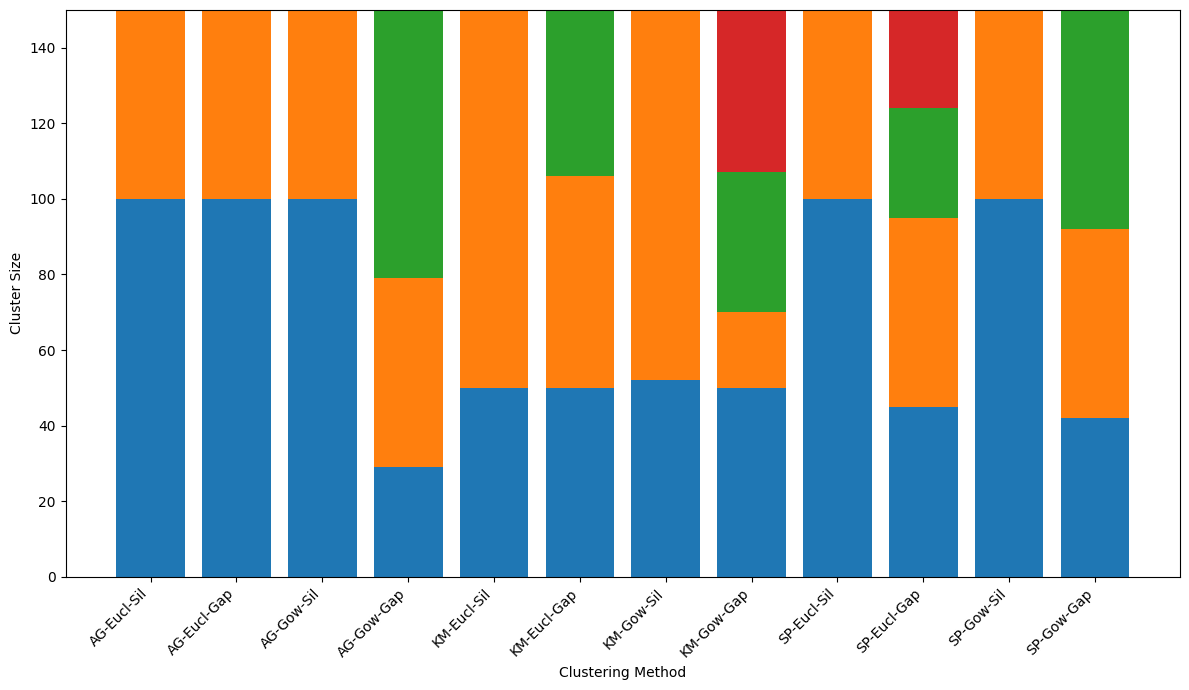

In [27]:
# Build the data list
data = []
for method in methods:
    cluster_counts = Counter(check_seed[f"{method}_lab"][0])
    for cluster, size in cluster_counts.items():
        data.append({"Method": method, "Cluster": f"Cluster {cluster}", "Size": size})

# Create DataFrame and pivot
df_plot = pd.DataFrame(data)
df_pivot = df_plot.pivot(index="Method", columns="Cluster", values="Size").fillna(0)

# Create the plot
plt.figure(figsize=(12, 7))

# Use a colormap with enough distinct colors
unique_clusters = df_plot['Cluster'].unique()
n_clusters = len(unique_clusters)

# Combine tab10 and Set3 to get enough distinct colors
colors_tab20 = plt.cm.get_cmap('tab10').colors
colors_tab20b = plt.cm.get_cmap('Set3').colors
all_colors = colors_tab20 + colors_tab20b  

# Assign a unique color to each cluster
cluster_colors = {cluster: all_colors[i % len(all_colors)] for i, cluster in enumerate(unique_clusters)}

# Stacked bar plot
bottom_values = np.zeros(len(df_pivot))
for i, cluster in enumerate(df_pivot.columns):
    plt.bar(df_pivot.index, df_pivot[cluster], label=cluster, bottom=bottom_values, color=cluster_colors[cluster])
    bottom_values += df_pivot[cluster].values

# Add labels and formatting
plt.xticks(ticks=[
    "km_eucl_alternate", "km_gow_alternate", "km_eucl_alternate_gap", "km_gow_alternate_gap",
    "ag_eucl_avg", "ag_gow_avg", "ag_eucl_avg_gap", "ag_gow_avg_gap",
    "sp_eucl_3", "sp_gow_3", "sp_eucl_3_gap", "sp_gow_3_gap"
], labels=[
    "KM-Eucl-Sil", "KM-Gow-Sil", "KM-Eucl-Gap", "KM-Gow-Gap",
    "AG-Eucl-Sil", "AG-Gow-Sil", "AG-Eucl-Gap", "AG-Gow-Gap",
    "SP-Eucl-Sil", "SP-Gow-Sil", "SP-Eucl-Gap", "SP-Gow-Gap"
], rotation=45, ha="right")

plt.ylabel("Cluster Size")
plt.xlabel("Clustering Method")
plt.tight_layout()

# Save plot
plt.savefig('/Users/achacko/Library/CloudStorage/OneDrive-UMCUtrecht/CLUSTERING PROJECT/Cluster sizes.png')
plt.show()


In [29]:
summary_rows = []

for i in methods:
    cluster_counts = Counter(check_seed[f"{i}_lab"][0])
    sizes = np.array(sorted(cluster_counts.values()))

    smallest = sizes.min()
    largest = sizes.max()
    median = np.median(sizes)
    mean = sizes.mean()

    n_clusters = check_seed[f"{i}_n"][0]

    # Append row to the list
    summary_rows.append({
        "Method": i,
        "Optimal Cluster Size": n_clusters,
        "Smallest Cluster Size": smallest,
        "Largest Cluster Size": largest,
        "Median Cluster Size": median,
        "Mean Cluster Size": round(mean, 2)
    })

# Create DataFrame from the list
summary_table = pd.DataFrame(summary_rows)

# Show the table
summary_table


,Method,Optimal Cluster Size,Smallest Cluster Size,Largest Cluster Size,Median Cluster Size,Mean Cluster Size
0,km_eucl_alternate,2,50,100,75.0,75.0
1,km_gow_alternate,2,52,98,75.0,75.0
2,km_eucl_alternate_gap,3,44,56,50.0,50.0
3,km_gow_alternate_gap,4,20,50,40.0,37.5
4,ag_eucl_avg,2,50,100,75.0,75.0
5,ag_gow_avg,2,50,100,75.0,75.0
6,ag_eucl_avg_gap,2,50,100,75.0,75.0
7,ag_gow_avg_gap,3,29,71,50.0,50.0
8,sp_eucl_3,2,50,100,75.0,75.0
9,sp_gow_3,2,50,100,75.0,75.0


In [30]:
Counter(df1['species'])

Counter({'setosa': 50, 'versicolor': 50, 'virginica': 50})

### PLOTS

In [31]:
df2[features]

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [32]:
data = []

df_cluster=df2[features]

for method in methods:
    column_name = f"{method}_lab"

    cluster_labels = check_seed[column_name][0] 
    
    for cluster in np.unique(cluster_labels):  
        cluster_data = df_cluster.loc[cluster_labels == cluster]  
        
        #Calculating mean and std for each variable in the cluster
        for var in df_cluster.columns:
            mean_value = cluster_data[var].mean()  
            std_value = cluster_data[var].std()
            data.append({'Method': method, 'Cluster': cluster, 'Variable': var, 'Mean': mean_value,'Std': std_value})

cluster_summary = pd.DataFrame(data)

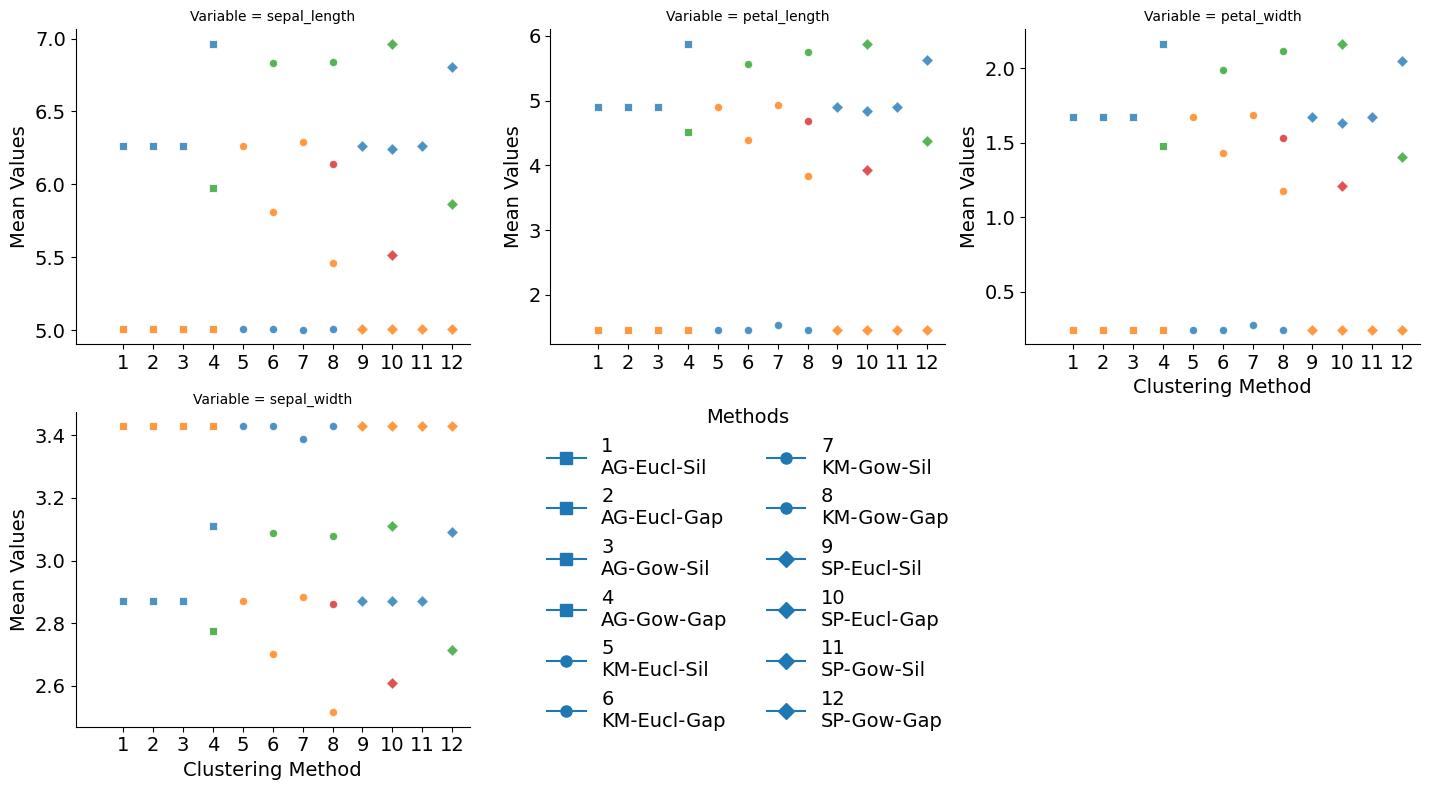

In [34]:
def get_marker(method):
    if method.startswith("km"):
        return "o"  # Circle marker for K-Medoids
    elif method.startswith("ag"):
        return "s"  # Square marker for Agglomerative Clustering
    elif method.startswith("sp"):
        return "D"  # diamond marker for Spectral Clustering


# Define a custom color palette for clusters
custom_palette = sns.color_palette("tab10", n_colors=len(cluster_summary["Cluster"].unique()))

# Filter for selected methods
data_vis = cluster_summary[cluster_summary["Method"].isin(methods)]


# Define marker styles dynamically
marker_styles = {m: get_marker(m) for m in data_vis["Method"].unique()}
custom_method_names = {'km_eucl_alternate':'KM-Eucl-Sil', 'km_gow_alternate':'KM-Gow-Sil', 'km_eucl_alternate_gap':'KM-Eucl-Gap',
       'km_gow_alternate_gap':'KM-Gow-Gap', 'ag_eucl_avg':'AG-Eucl-Sil', 'ag_gow_avg':'AG-Gow-Sil',
       'ag_eucl_avg_gap':'AG-Eucl-Gap', 'ag_gow_avg_gap':'AG-Gow-Gap', 'sp_eucl_3':'SP-Eucl-Sil', 'sp_gow_3':'SP-Gow-Sil',
       'sp_eucl_3_gap':'SP-Eucl-Gap', 'sp_gow_3_gap':'SP-Gow-Gap'
                      }

# Create a mapping of method name to number
method_list = sorted(data_vis["Method"].unique())
method_to_num = {name: f"{i+1}" for i, name in enumerate(method_list)}
# Replace Method column with numbers for plotting
data_vis["MethodNum"] = data_vis["Method"].map(method_to_num).astype(int)
data_vis = data_vis.sort_values(by="MethodNum")
data_vis["MethodDisplay"] = data_vis["Method"].map(custom_method_names)

dummy_row = {
    "Variable": "dummy_legend",
    "Method": methods[0],          
    "Mean": 0,                     
    "Cluster": cluster_summary["Cluster"].unique()[0],  
    "MethodNum": 0,
    "MethodDisplay": "dummy"
}
data_vis_with_dummy = pd.concat([data_vis, pd.DataFrame([dummy_row])], ignore_index=True)


# Disable automatic legend on the main plots
g = sns.FacetGrid(data_vis_with_dummy, col="Variable", col_wrap=3, sharey=False, height=4,aspect=1.2)

g.map_dataframe(
    sns.lineplot,
    x="MethodNum",
    y="Mean",
    hue="Cluster",
    palette=custom_palette,
    style="Method",
    markers=marker_styles,
    alpha=0.8,
    legend=False  
)

# Prepare handles and labels for custom method legend
import matplotlib.lines as mlines
from matplotlib.ticker import FixedLocator, FixedFormatter

# Create custom legend handles for methods with correct marker and color for the first cluster
first_cluster = cluster_summary["Cluster"].unique()[0]
custom_handles = []
custom_labels = []
for method in method_list:
    # marker style
    marker = marker_styles[method]
    # color from first cluster in your palette
    color = custom_palette[0]  # you can pick cluster color you like, or just black
    # create a Line2D handle with marker and color
    handle = mlines.Line2D([], [], color=color, marker=marker, linestyle='-', markersize=8)
    custom_handles.append(handle)
    # two-line label: method number and method display
    label = f"{method_to_num[method]}\n{custom_method_names[method]}"
    custom_labels.append(label)



# Add the legend to the dummy subplot
for ax in g.axes.flat:
    var_name = ax.get_title().split(" = ")[-1]
    if var_name == "dummy_legend":
        ax.clear()
        ax.axis('off')
        ax.legend(custom_handles, custom_labels, title="Methods", loc='center', frameon=False,ncol=2,fontsize=14,title_fontsize=14)
    else:
        ticks = sorted(data_vis["MethodNum"].unique())

        labels = [method_to_num[m] for m in method_list]  

        ax.xaxis.set_major_locator(FixedLocator(ticks))
        ax.xaxis.set_major_formatter(FixedFormatter(labels))
        

        ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True,labelsize=14)  
        ax.tick_params(axis='y', labelsize=14)  
        
        ax.set_xlabel("Clustering Method",fontsize=14)
        ax.set_ylabel("Mean Values",fontsize=14)
       
       


plt.subplots_adjust(top=1.0)


for ax in g.axes.flat:
    ax.set_xticks(ticks)  
    ax.set_xticklabels(labels)  

plt.tight_layout()
plt.savefig('/Users/achacko/Library/CloudStorage/OneDrive-UMCUtrecht/CLUSTERING PROJECT/Mean across clusters.png')
plt.show()

#### UPSET PLOTS

In [35]:
from upsetplot import UpSet, from_indicators
from itertools import combinations

In [ ]:
# For Euclidean  methods

methods = {
    "KM-Eucl-Sil": check_seed["km_eucl_alternate_lab"][0],
    "AG-Eucl-Sil": check_seed["ag_eucl_avg_lab"][0],
    "SP-Eucl-Sil": check_seed["sp_eucl_3_lab"][0],
    "KM-Eucl-Gap": check_seed["km_eucl_alternate_gap_lab"][0],
    "AG-Eucl-Gap": check_seed["ag_eucl_avg_gap_lab"][0],
    "SP-Eucl-Gap": check_seed["sp_eucl_3_gap_lab"][0],
   
}

# Generate patient-pair same-group boolean indicators for each method
def get_pairwise_co_cluster(labels):
    n = len(labels)
    pair_co_cluster = {}
    for i, j in combinations(range(n), 2):
        pair_co_cluster[(i, j)] = labels[i] == labels[j]  
    return pair_co_cluster

# Combine all methods' co-clustering into one dataframe
pair_index = list(combinations(range(len(check_seed["km_eucl_alternate_lab"][0])), 2))
agreement_df = pd.DataFrame(index=pair_index)

for name, labels in methods.items():
    agreement_df[name] = pd.Series(get_pairwise_co_cluster(labels))

# Convert to UpSet-friendly format
upset_data = from_indicators(agreement_df.columns, agreement_df)


<Figure size 1200x800 with 0 Axes>

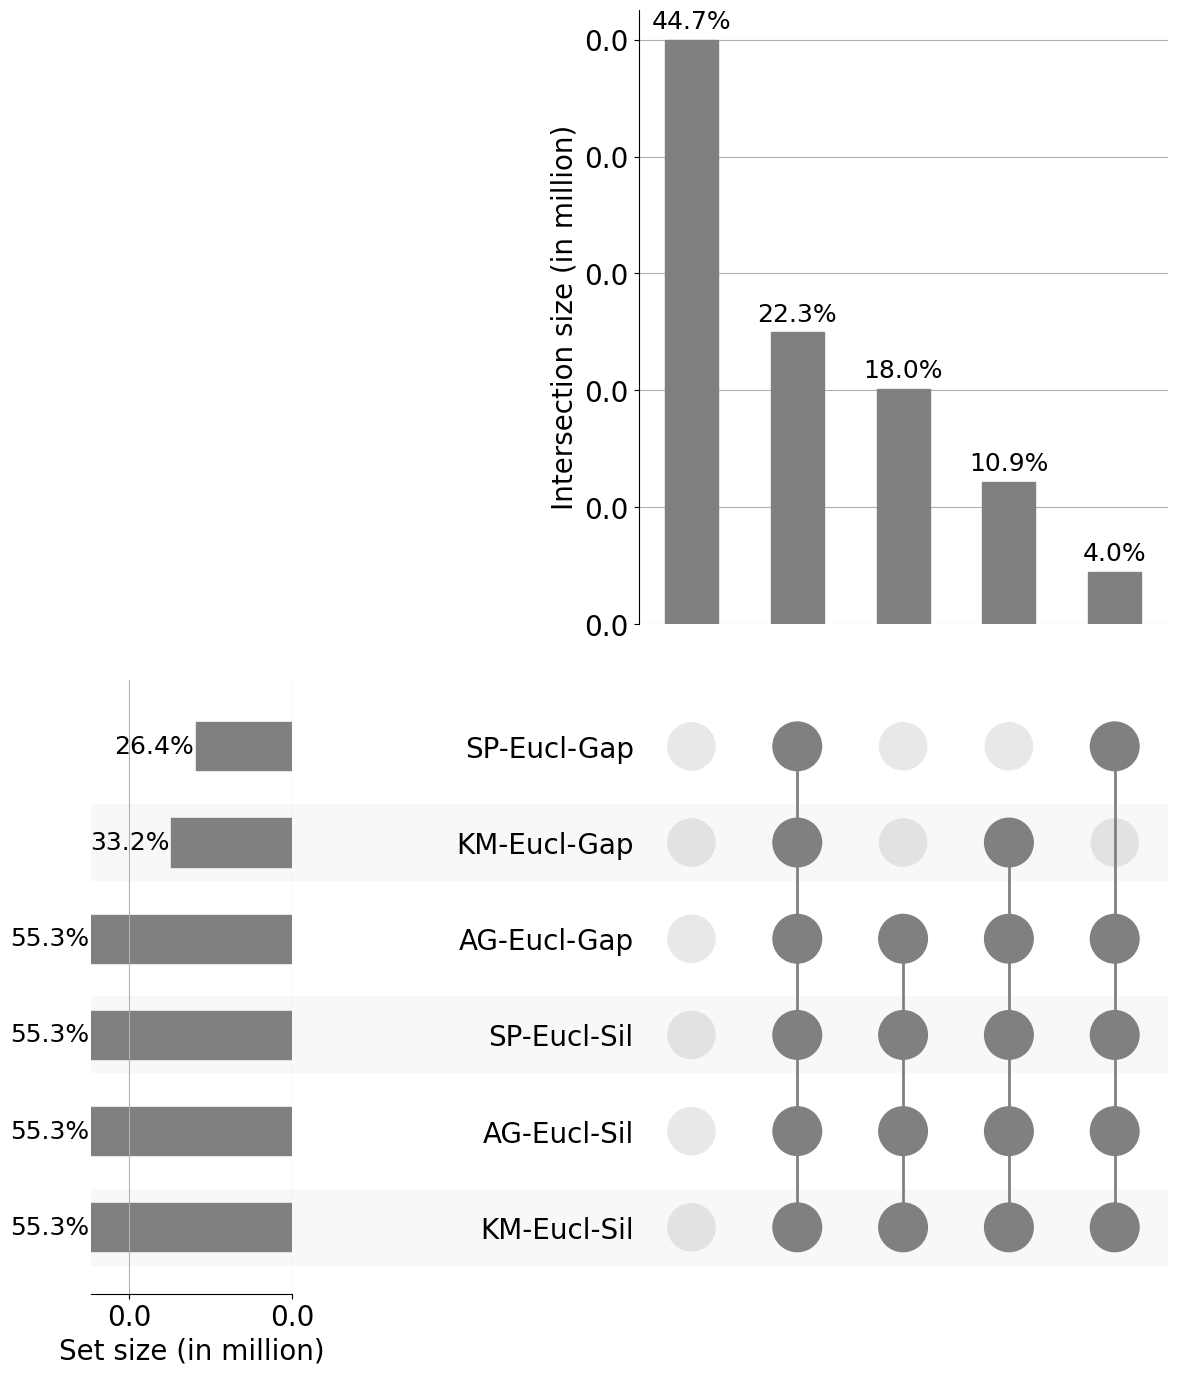

In [43]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12, 8))

plt.rcParams.update({
    'font.size': 18,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20
})

upset = UpSet(
    upset_data,
    subset_size='count',
    show_percentages=True,
    sort_by='cardinality',
    element_size=100,
    facecolor='gray'
)

# Create plot and capture axes
axes = upset.plot()

# Formatter to show values in millions
def millions(x, pos):
    return f"{x/1e6:.1f}"

# Intersection bars (top)
ax_int = axes["intersections"]
ax_int.yaxis.set_major_formatter(FuncFormatter(millions))
ax_int.set_ylabel("Intersection size (in million)")

# Total set bars (left)
ax_tot = axes["totals"]
ax_tot.xaxis.set_major_formatter(FuncFormatter(millions))
ax_tot.set_xlabel("Set size (in million)")

plt.show()


In [44]:
# For Gower  methods

methods = {
    "KM-Gow-Sil": check_seed["km_gow_alternate_lab"][0],
    "AG-Gow-Sil": check_seed["ag_gow_avg_lab"][0],
    "Sp-Gow-Sil": check_seed["sp_gow_3_lab"][0],
    "KM-Gow-Gap": check_seed["km_gow_alternate_gap_lab"][0],
    "AG-Gow-Gap": check_seed["ag_gow_avg_gap_lab"][0],
    "Sp-Gow-Gap": check_seed["sp_gow_3_gap_lab"][0]
   
}

# Generate patient-pair same-group boolean indicators for each method
def get_pairwise_co_cluster(labels):
    n = len(labels)
    pair_co_cluster = {}
    for i, j in combinations(range(n), 2):
        pair_co_cluster[(i, j)] = labels[i] == labels[j]  
    return pair_co_cluster

# Combine all methods' co-clustering into one dataframe
pair_index = list(combinations(range(len(check_seed["km_gow_alternate_lab"][0])), 2))
agreement_df = pd.DataFrame(index=pair_index)

for name, labels in methods.items():
    agreement_df[name] = pd.Series(get_pairwise_co_cluster(labels))

# Convert to UpSet-friendly format
upset_data_1 = from_indicators(agreement_df.columns, agreement_df)

<Figure size 1200x800 with 0 Axes>

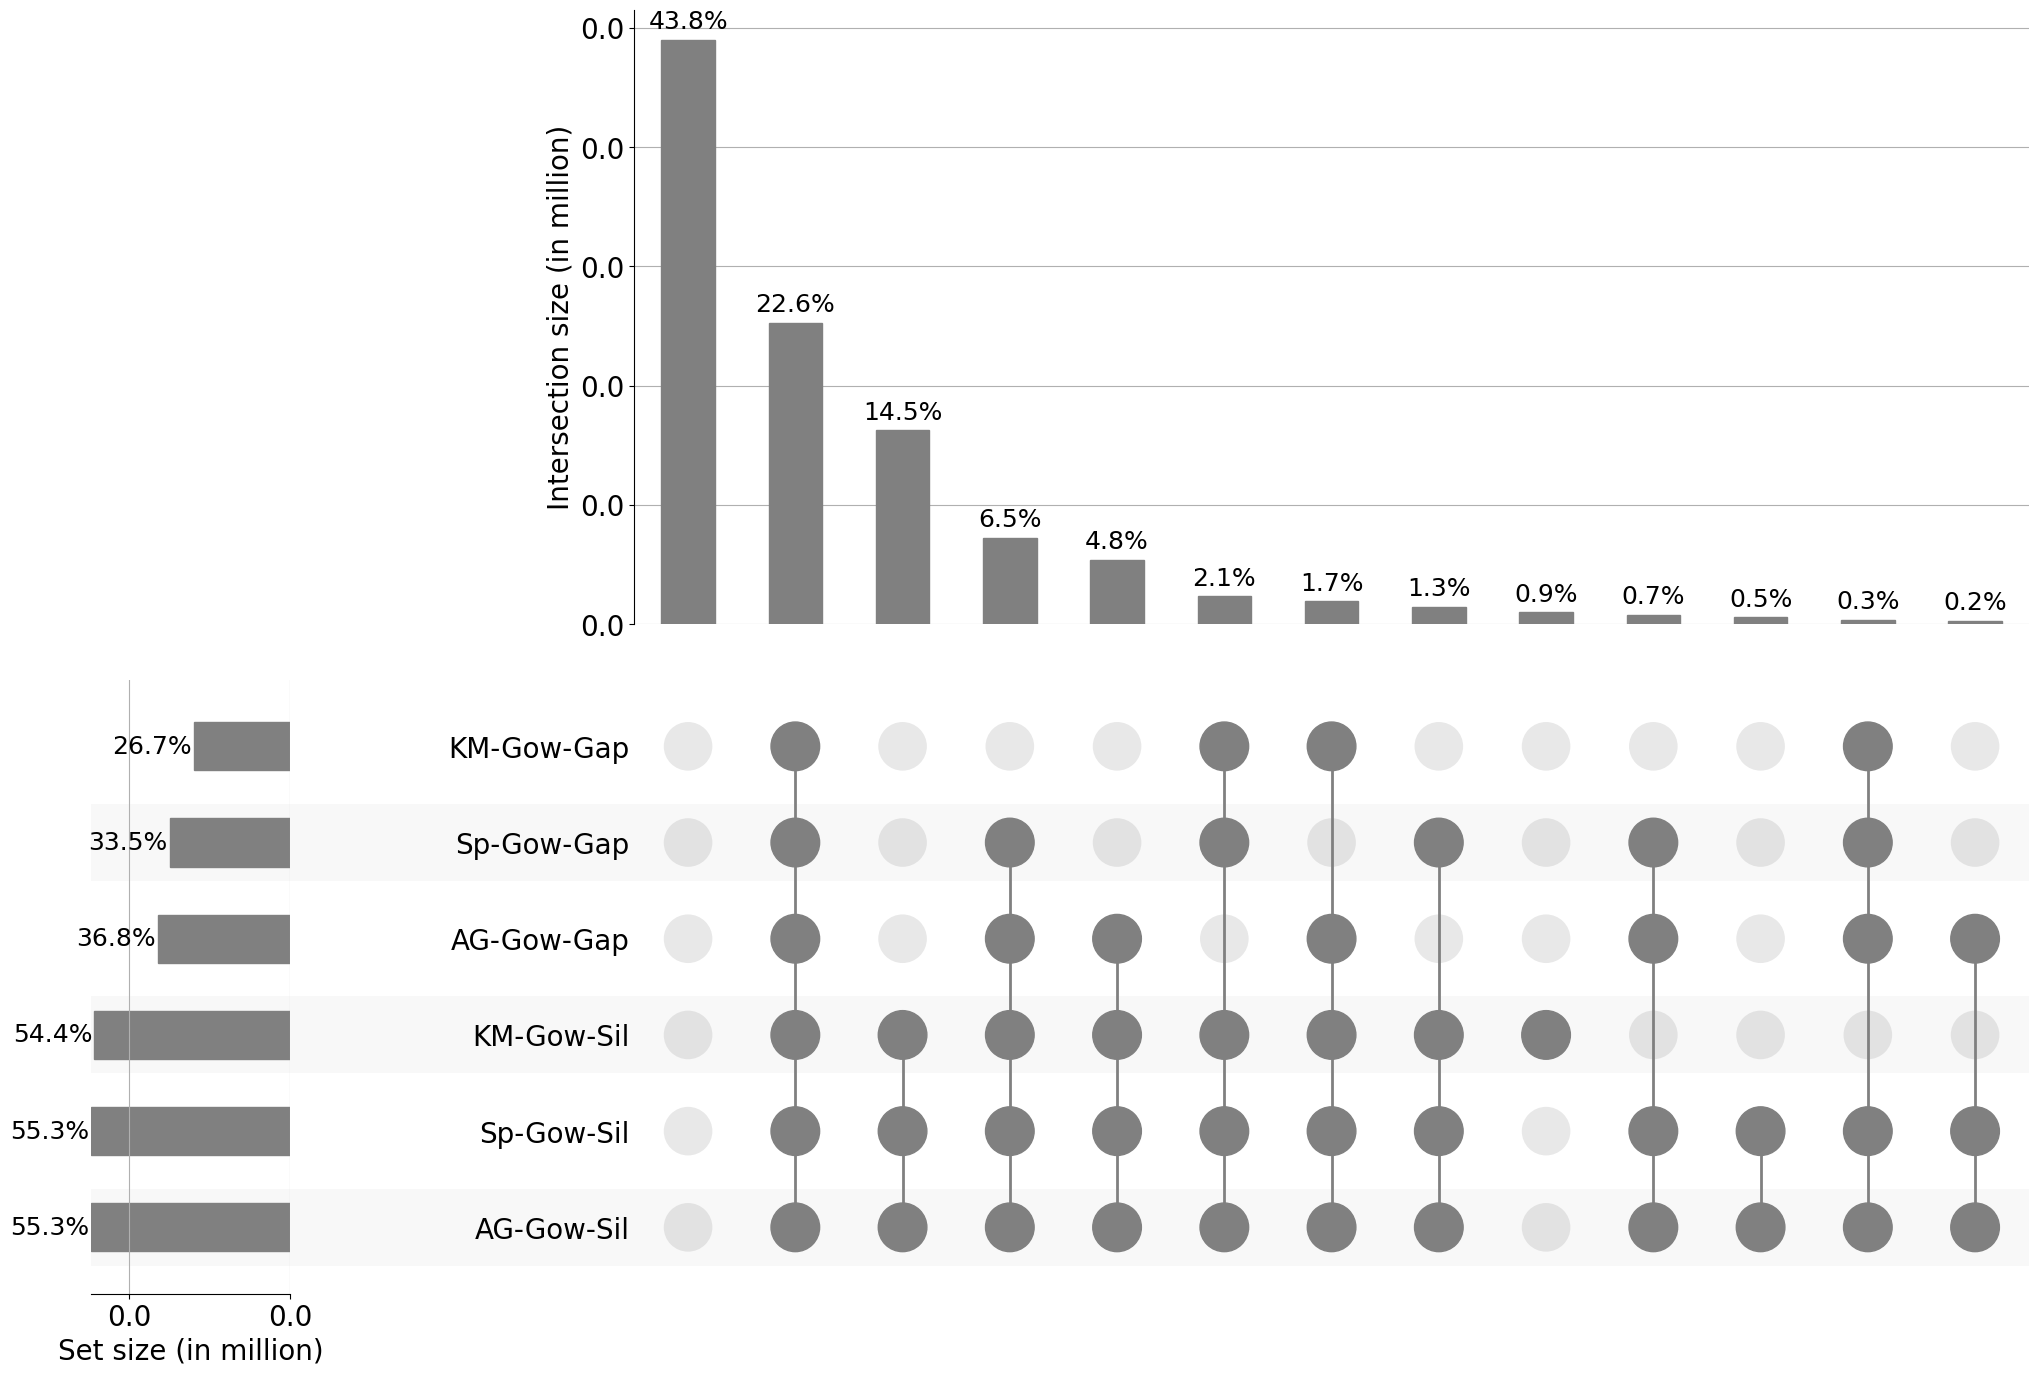

In [45]:
# Create and customize UpSet plot
plt.figure(figsize=(12, 8))  # Bigger plot


# Set global font size parameters
plt.rcParams.update({
    'font.size': 18,         
    'xtick.labelsize': 20,   
    'ytick.labelsize': 20,   
    'axes.titlesize': 20,    
    'axes.labelsize': 20     
})
upset = UpSet(
    upset_data_1,  
    subset_size='count',  
    show_percentages=True,
    #show_counts=True,
    sort_by='cardinality',  # Sort from largest to smallest bar
    element_size=100,  # Increase spacing between bars
    facecolor='gray' 
)

# Create plot and capture axes
axes = upset.plot()

# Formatter to show values in millions
def millions(x, pos):
    return f"{x/1e6:.1f}"

# Intersection bars (top)
ax_int = axes["intersections"]
ax_int.yaxis.set_major_formatter(FuncFormatter(millions))
ax_int.set_ylabel("Intersection size (in million)")

# Total set bars (left)
ax_tot = axes["totals"]
ax_tot.xaxis.set_major_formatter(FuncFormatter(millions))
ax_tot.set_xlabel("Set size (in million)")

# Set the title
plt.savefig('/Users/achacko/Library/CloudStorage/OneDrive-UMCUtrecht/CLUSTERING PROJECT/upset2.png')

# Show the plot
plt.show()

#### RAND INDEX AND ADJUSTED RAND INDEX

In [46]:
methods=["km_eucl_alternate", "km_gow_alternate",  "km_eucl_alternate_gap", "km_gow_alternate_gap",  "ag_eucl_avg", "ag_gow_avg",  
        "ag_eucl_avg_gap", "ag_gow_avg_gap", "sp_eucl_3",  "sp_gow_3", "sp_eucl_3_gap",  "sp_gow_3_gap"
        ]
methods

['km_eucl_alternate',
 'km_gow_alternate',
 'km_eucl_alternate_gap',
 'km_gow_alternate_gap',
 'ag_eucl_avg',
 'ag_gow_avg',
 'ag_eucl_avg_gap',
 'ag_gow_avg_gap',
 'sp_eucl_3',
 'sp_gow_3',
 'sp_eucl_3_gap',
 'sp_gow_3_gap']

In [47]:
results=[]

for meth in methods:
    for meth1 in methods:
        ri= rand_score(check_seed[f"{meth}_lab"][0], check_seed[f"{meth1}_lab"][0])
        ari = adjusted_rand_score(check_seed[f"{meth}_lab"][0], check_seed[f"{meth1}_lab"][0])
        
        results.append({"Method 1": meth, "Method 2": meth1, "Rand Index": ri, "Adjusted Rand Index": ari})

# Convert the results into a DataFrame
df_stability_results = pd.DataFrame(results)
df_stability_results

,Method 1,Method 2,Rand Index,Adjusted Rand Index
0,km_eucl_alternate,km_eucl_alternate,1.000000,1.000000
1,km_eucl_alternate,km_gow_alternate,0.973512,0.946530
2,km_eucl_alternate,km_eucl_alternate_gap,0.779508,0.574057
3,km_eucl_alternate,km_gow_alternate_gap,0.714452,0.455577
4,km_eucl_alternate,ag_eucl_avg,1.000000,1.000000
...,...,...,...,...
139,sp_gow_3_gap,ag_gow_avg_gap,0.898792,0.778265
140,sp_gow_3_gap,sp_eucl_3,0.782013,0.578682
141,sp_gow_3_gap,sp_gow_3,0.782013,0.578682
142,sp_gow_3_gap,sp_eucl_3_gap,0.854586,0.655254


In [48]:
df_ri = df_stability_results.pivot(index="Method 1", columns="Method 2", values="Rand Index")
df_ari = df_stability_results.pivot(index="Method 1", columns="Method 2", values="Adjusted Rand Index")


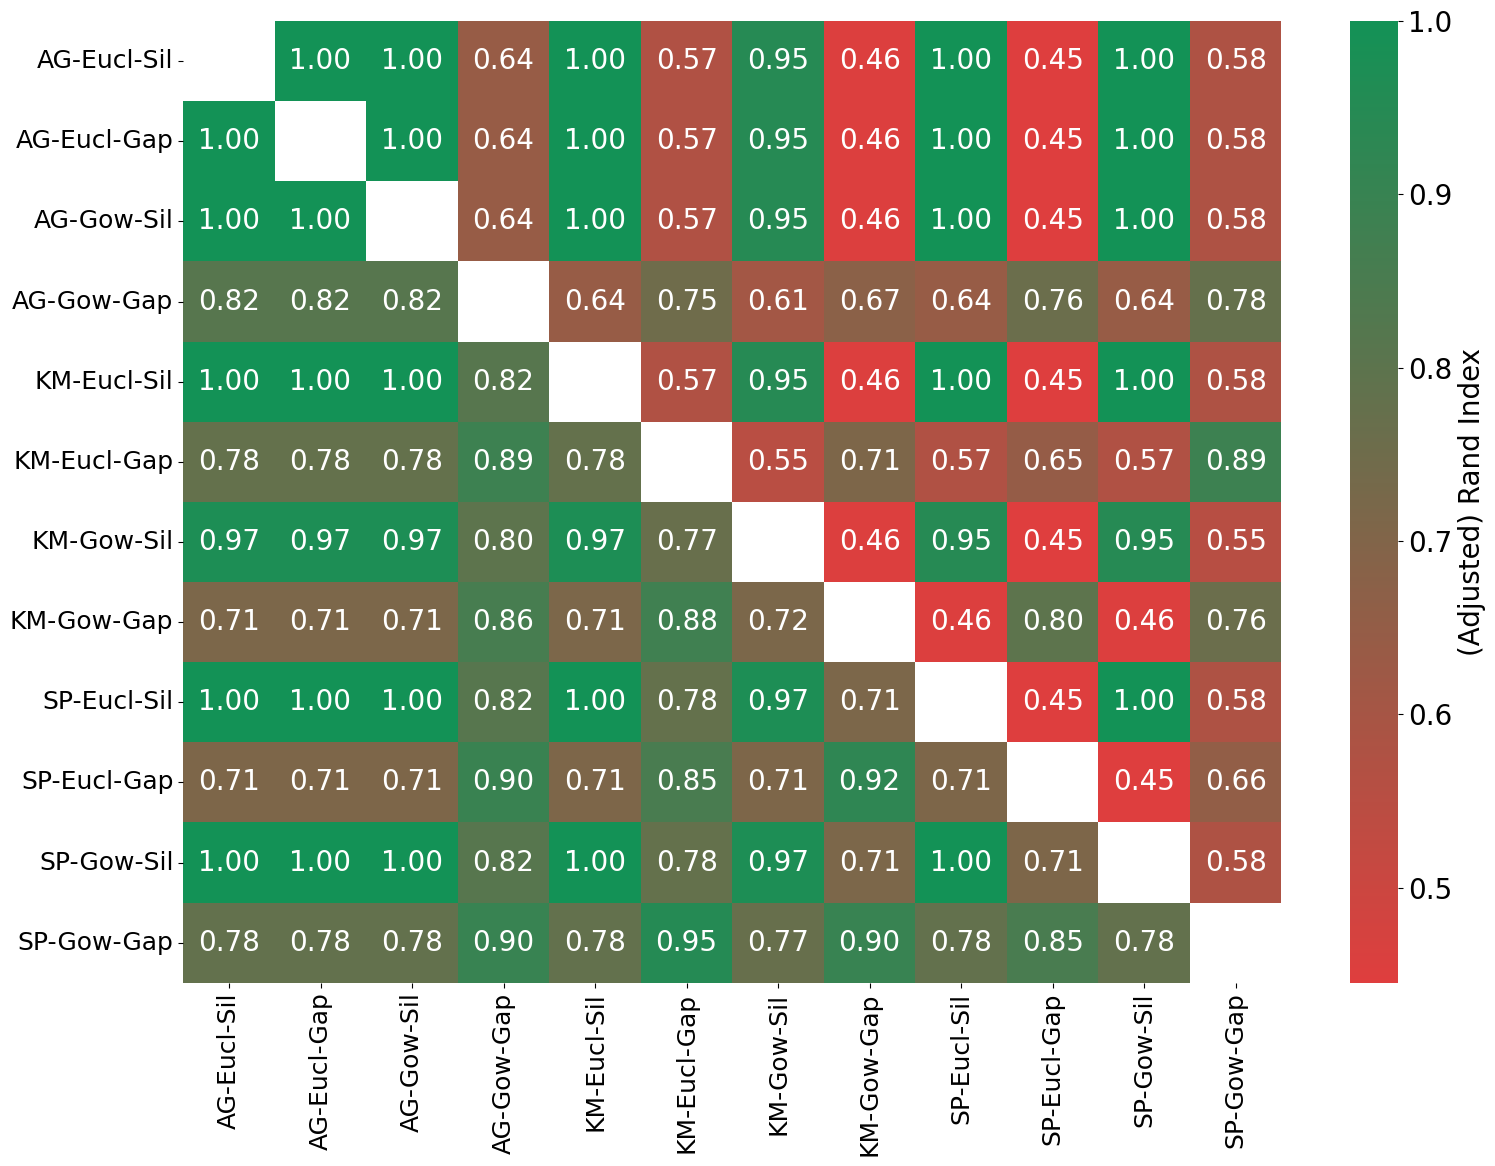

In [49]:
import matplotlib.colors as mcolors

# Create a custom diverging colormap: green -> red

red = "#DF3E3E"
green = "#139256"
colors = [red, green]
cmap = mcolors.LinearSegmentedColormap.from_list("RedGreen", colors, N=256)

# Create a combined matrix initialized with NaNs
combined_matrix = np.full(df_ri.shape, np.nan)

custom_method_names = {'km_eucl_alternate':'KM-Eucl-Sil', 'km_gow_alternate':'KM-Gow-Sil', 'km_eucl_alternate_gap':'KM-Eucl-Gap',
       'km_gow_alternate_gap':'KM-Gow-Gap', 'ag_eucl_avg':'AG-Eucl-Sil', 'ag_gow_avg':'AG-Gow-Sil',
       'ag_eucl_avg_gap':'AG-Eucl-Gap', 'ag_gow_avg_gap':'AG-Gow-Gap', 'sp_eucl_3':'SP-Eucl-Sil', 'sp_gow_3':'SP-Gow-Sil',
       'sp_eucl_3_gap':'SP-Eucl-Gap', 'sp_gow_3_gap':'SP-Gow-Gap'
                      }

xtick_labels = [custom_method_names.get(label, label) for label in df_ri.columns]
ytick_labels = [custom_method_names.get(label, label) for label in df_ri.index]

# Fill lower triangle with Rand Index (RI)
for i in range(len(df_ri)):
    for j in range(i):  # Only lower diagonal
        combined_matrix[i, j] = df_ri.iloc[i, j]

# Fill upper triangle with Adjusted Rand Index (ARI)
for i in range(len(df_ari)):
    for j in range(i+1, len(df_ari)):  # Only upper diagonal
        combined_matrix[i, j] = df_ari.iloc[i, j]

# Create a mask to hide diagonal elements 
mask = np.eye(combined_matrix.shape[0], dtype=bool)  # Mask diagonal

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(combined_matrix, annot=True, cmap=cmap, fmt=".2f", mask=mask, cbar_kws={'label': '(Adjusted) Rand Index'},  annot_kws={"size": 20} )

# Set labels
plt.xticks(ticks=np.arange(len(df_ri))+0.5, labels=xtick_labels, rotation=90, ha="center",fontsize=18)
plt.yticks(ticks=np.arange(len(df_ri))+0.5, labels=ytick_labels, rotation=0,va="center",fontsize=18)


for label in plt.gca().get_yticklabels():
    label.set_verticalalignment("center")
    
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.savefig('/Users/achacko/Library/CloudStorage/OneDrive-UMCUtrecht/CLUSTERING PROJECT/Rand Index.png')  # Specify the file path and name
plt.show()
           